<a href="https://colab.research.google.com/github/AliRaddman/ai-bootcamp-DeepLearning/blob/main/03_cv_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" align="right">

# مدل پایه تشخیص تصادف

## ۱. اتصال Google Drive و شناسایی مسیر پروژه

در این مرحله Google Drive متصل می‌شود و مسیر پوشه مشترک پروژه به‌صورت خودکار پیدا می‌شود.

برای جلوگیری از وابستگی کد به نام میان‌بر، پوشه‌ای انتخاب می‌شود که فایل `train_split.csv` داخل آن وجود داشته باشد.

</div>

In [2]:
from pathlib import Path
from google.colab import drive

# اتصال Google Drive
drive.mount("/content/drive")

MY_DRIVE = Path("/content/drive/MyDrive")

# پیدا کردن پوشه واقعی پروژه
project_candidates = list(MY_DRIVE.glob("AI_Project2*"))

valid_roots = [
    root
    for root in project_candidates
    if (root / "outputs/cv/train_split.csv").is_file()
]

if len(valid_roots) != 1:
    raise RuntimeError(
        f"Expected exactly one valid project folder, found {len(valid_roots)}: "
        f"{[str(path) for path in valid_roots]}"
    )

PROJECT_ROOT = valid_roots[0]

CV_DATA_DIR = PROJECT_ROOT / "data/cv"
CV_MODEL_DIR = PROJECT_ROOT / "models/cv"
CV_OUTPUT_DIR = PROJECT_ROOT / "outputs/cv"

CV_MODEL_DIR.mkdir(parents=True, exist_ok=True)
CV_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", CV_DATA_DIR)
print("Model directory:", CV_MODEL_DIR)
print("Output directory:", CV_OUTPUT_DIR)

Mounted at /content/drive
Project root: /content/drive/MyDrive/AI_Project2
Data directory: /content/drive/MyDrive/AI_Project2/data/cv
Model directory: /content/drive/MyDrive/AI_Project2/models/cv
Output directory: /content/drive/MyDrive/AI_Project2/outputs/cv


<div dir="rtl" align="right">

## ۲. بارگذاری و اعتبارسنجی فایل‌های داده

در این مرحله فایل‌های آموزش، اعتبارسنجی و فهرست فریم‌ها بارگذاری می‌شوند.

موارد زیر بررسی می‌شوند:

- وجود فایل‌ها
- تعداد فریم‌ها و ویدئوها
- توزیع کلاس‌ها
- نبود هم‌پوشانی ویدئوهای Train و Validation

</div>

In [3]:
import pandas as pd

TRAIN_CSV = CV_OUTPUT_DIR / "train_split.csv"
VAL_CSV = CV_OUTPUT_DIR / "validation_split.csv"
MASTER_CSV = CV_OUTPUT_DIR / "dataset_master.csv"

for path in [TRAIN_CSV, VAL_CSV, MASTER_CSV]:
    if not path.is_file():
        raise FileNotFoundError(f"File not found: {path}")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
master_df = pd.read_csv(MASTER_CSV)

train_ids = set(train_df["video_id"].astype(str))
val_ids = set(val_df["video_id"].astype(str))
overlap = train_ids & val_ids

assert not overlap, f"Data leakage detected: {len(overlap)} overlapping videos."

print("Train frames:", len(train_df))
print("Train videos:", train_df["video_id"].nunique())

print("\nValidation frames:", len(val_df))
print("Validation videos:", val_df["video_id"].nunique())

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nMaster shape:", master_df.shape)
print("Overlapping videos:", len(overlap))

Train frames: 5972
Train videos: 80

Validation frames: 1618
Validation videos: 20

Train labels:
label
positive    3059
negative    2913
Name: count, dtype: int64

Validation labels:
label
positive    810
negative    808
Name: count, dtype: int64

Master shape: (7590, 5)
Overlapping videos: 0


<div dir="rtl" align="right">

## ۳. تنظیم Seed و بررسی GPU

برای تکرارپذیر بودن نتایج، مقدار Seed ثابت می‌شود. سپس سخت‌افزار اجرای PyTorch بررسی خواهد شد.

مدل باید روی GPU آموزش داده شود؛ در این پروژه انتظار داریم دستگاه `T4` شناسایی شود.

</div>

In [4]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("GPU فعال نیست. Runtime را روی T4 GPU قرار بده.")

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


<div dir="rtl" align="right">

## ۴. بررسی ساختار فایل Train

در این مرحله نام ستون‌های فایل آموزش و چند ردیف اول آن نمایش داده می‌شود تا ستون واقعی مسیر فریم مشخص شود.

</div>

In [5]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nFirst rows:")
display(train_df.head())

Train columns:
['video_id', 'split', 'dataset_split', 'class', 'label', 'frame_index', 'timestamp_sec', 'processed_relpath', 'processed_path', 'fps', 'duration_sec', 'width', 'height']

First rows:


,video_id,split,dataset_split,class,label,frame_index,timestamp_sec,processed_relpath,processed_path,fps,duration_sec,width,height
0,0,train,train,positive,positive,0,0.000,train/positive/00000/frame_0000.jpg,/content/scratch/frames_processed/train/positi...,28.9,40.07,1280,720
1,0,train,train,positive,positive,1,0.484,train/positive/00000/frame_0001.jpg,/content/scratch/frames_processed/train/positi...,28.9,40.07,1280,720
2,0,train,train,positive,positive,2,0.969,train/positive/00000/frame_0002.jpg,/content/scratch/frames_processed/train/positi...,28.9,40.07,1280,720
3,0,train,train,positive,positive,3,1.453,train/positive/00000/frame_0003.jpg,/content/scratch/frames_processed/train/positi...,28.9,40.07,1280,720
4,0,train,train,positive,positive,4,1.938,train/positive/00000/frame_0004.jpg,/content/scratch/frames_processed/train/positi...,28.9,40.07,1280,720


<div dir="rtl" align="right">

## ۴. ساخت و اعتبارسنجی مسیر کامل فریم‌ها

در فایل‌های Split، مسیر نسبی هر فریم در ستون `processed_relpath` قرار دارد.

در این مرحله مسیر کامل فریم‌ها ساخته می‌شود و بررسی می‌کنیم که تمام تصاویر Train و Validation واقعاً در Google Drive وجود داشته باشند.

</div>

In [6]:
from pathlib import Path

FRAMES_DIR = CV_OUTPUT_DIR / "frames_processed"

train_df["frame_path"] = train_df["processed_relpath"].apply(
    lambda relative_path: str(FRAMES_DIR / relative_path)
)

val_df["frame_path"] = val_df["processed_relpath"].apply(
    lambda relative_path: str(FRAMES_DIR / relative_path)
)

train_exists = train_df["frame_path"].apply(lambda path: Path(path).is_file())
val_exists = val_df["frame_path"].apply(lambda path: Path(path).is_file())

print("Train frames found:", train_exists.sum(), "/", len(train_df))
print("Validation frames found:", val_exists.sum(), "/", len(val_df))
print("Sample path:", train_df.iloc[0]["frame_path"])

assert train_exists.all(), "Some Train frames are missing."
assert val_exists.all(), "Some Validation frames are missing."

Train frames found: 0 / 5972
Validation frames found: 0 / 1618
Sample path: /content/drive/MyDrive/AI_Project2/outputs/cv/frames_processed/train/positive/00000/frame_0000.jpg


AssertionError: Some Train frames are missing.

<div dir="rtl" align="right">

## ۴. پیدا کردن مسیر واقعی فریم‌ها

در این مرحله محل واقعی پوشه فریم‌های پردازش‌شده در Google Drive پیدا می‌شود.

هیچ فایلی تغییر نمی‌کند و فقط مسیرهایی که شامل تصویر نمونه هستند نمایش داده می‌شوند.

</div>

In [7]:
from pathlib import Path

sample_relative_path = Path(
    train_df.iloc[0]["processed_relpath"]
)

search_root = Path("/content/drive/MyDrive")

matching_paths = [
    path
    for path in search_root.rglob(sample_relative_path.name)
    if path.as_posix().endswith(sample_relative_path.as_posix())
]

print("Sample relative path:", sample_relative_path)
print("Matches found:", len(matching_paths))

for path in matching_paths:
    print(path)

Sample relative path: train/positive/00000/frame_0000.jpg
Matches found: 0


<div dir="rtl" align="right">

## ۴. پیدا کردن پوشه واقعی فریم‌های پردازش‌شده

نام فایل‌های ثبت‌شده در فایل Split با نام تصاویر موجود یکسان نیست.  
در این مرحله تمام پوشه‌های `frames_processed` پیدا شده و تعداد تصاویر هرکدام بررسی می‌شود.

</div>

In [8]:
from pathlib import Path

search_root = Path("/content/drive/MyDrive")

frame_directories = [
    path
    for path in search_root.rglob("frames_processed")
    if path.is_dir()
]

print("Frame directories found:", len(frame_directories))

for directory in frame_directories:
    jpg_count = sum(1 for _ in directory.rglob("*.jpg"))
    print(f"{directory} | JPG files: {jpg_count}")

Frame directories found: 0


<div dir="rtl" align="right">

## ۴. بررسی محل قرارگیری Shortcut فریم‌ها

در این مرحله محتوای مستقیم پوشه `outputs/cv` نمایش داده می‌شود تا نام و محل واقعی Shortcut مربوط به فریم‌ها مشخص شود.

</div>

In [9]:
print("CV output directory:", CV_OUTPUT_DIR)
print("Exists:", CV_OUTPUT_DIR.exists())

print("\nDirect contents:")
for path in sorted(CV_OUTPUT_DIR.iterdir()):
    item_type = "directory" if path.is_dir() else "file"
    print(f"{path.name} | {item_type}")

CV output directory: /content/drive/MyDrive/AI_Project2/outputs/cv
Exists: True

Direct contents:
dataset_master.csv | file
dataset_master_fixed.csv | file
dataset_mean_std.json | file
frames_processed | directory
frames_processed (1) | directory
frames_processed (1) (1) | directory
temporal_validation_predictions.csv | file
train_split.csv | file
validation_split.csv | file


<div dir="rtl" align="right">

## ۴. انتخاب پوشه صحیح فریم‌ها

چند پوشه با نام مشابه `frames_processed` وجود دارد. در این مرحله تعداد تصاویر هر پوشه بررسی می‌شود تا پوشه صحیح برای ساخت Dataset انتخاب شود.

</div>

In [10]:
frame_candidates = [
    CV_OUTPUT_DIR / "frames_processed",
    CV_OUTPUT_DIR / "frames_processed (1)",
    CV_OUTPUT_DIR / "frames_processed (1) (1)",
]

for directory in frame_candidates:
    image_files = list(directory.rglob("*.jpg")) + list(directory.rglob("*.png"))

    print(f"\nFolder: {directory.name}")
    print("Images:", len(image_files))

    if image_files:
        print("Sample:", image_files[0])


Folder: frames_processed
Images: 9227
Sample: /content/drive/MyDrive/AI_Project2/outputs/cv/frames_processed/test-private/negative/01047/000000.jpg

Folder: frames_processed (1)
Images: 9227
Sample: /content/drive/MyDrive/AI_Project2/outputs/cv/frames_processed (1)/test-private/negative/01047/000000.jpg

Folder: frames_processed (1) (1)
Images: 9227
Sample: /content/drive/MyDrive/AI_Project2/outputs/cv/frames_processed (1) (1)/test-private/negative/01047/000000.jpg


<div dir="rtl" align="right">

## ۴. بررسی ساختار واقعی فریم‌های یک ویدئو

فایل‌های CSV نام‌هایی مانند `frame_0000.jpg` ثبت کرده‌اند، اما تصاویر موجود احتمالاً با قالبی مانند `000000.jpg` ذخیره شده‌اند.

در این مرحله پوشه مربوط به اولین ویدئوی Train بررسی می‌شود تا الگوی دقیق نام فایل‌ها مشخص شود.

</div>

In [11]:
FRAMES_DIR = CV_OUTPUT_DIR / "frames_processed"

sample_row = train_df.iloc[0]

sample_video_dir = (
    FRAMES_DIR
    / sample_row["dataset_split"]
    / sample_row["class"]
    / str(sample_row["video_id"]).zfill(5)
)

sample_images = sorted(sample_video_dir.glob("*.jpg"))

print("Video directory:", sample_video_dir)
print("Directory exists:", sample_video_dir.is_dir())
print("Number of frames:", len(sample_images))
print("First 10 filenames:")

for path in sample_images[:10]:
    print(path.name)

Video directory: /content/drive/MyDrive/AI_Project2/outputs/cv/frames_processed/train/positive/00000
Directory exists: True
Number of frames: 83
First 10 filenames:
000000.jpg
000001.jpg
000002.jpg
000003.jpg
000004.jpg
000005.jpg
000006.jpg
000007.jpg
000008.jpg
000009.jpg


<div dir="rtl" align="right">

## ۴. ساخت مسیر صحیح فریم‌ها

نام واقعی فریم‌ها به‌صورت شش‌رقمی مانند `000000.jpg` است.

در این مرحله مسیر هر فریم با استفاده از اطلاعات زیر ساخته می‌شود:

- بخش داده
- کلاس
- شناسه ویدئو
- شماره فریم

سپس وجود تمام فریم‌های Train و Validation بررسی می‌شود.

</div>

In [12]:
def build_frame_path(row):
    video_id = str(int(row["video_id"])).zfill(5)
    frame_name = f"{int(row['frame_index']):06d}.jpg"

    return str(
        FRAMES_DIR
        / row["dataset_split"]
        / row["class"]
        / video_id
        / frame_name
    )


train_df["frame_path"] = train_df.apply(build_frame_path, axis=1)
val_df["frame_path"] = val_df.apply(build_frame_path, axis=1)

train_exists = train_df["frame_path"].apply(lambda path: Path(path).is_file())
val_exists = val_df["frame_path"].apply(lambda path: Path(path).is_file())

print("Train frames found:", train_exists.sum(), "/", len(train_df))
print("Validation frames found:", val_exists.sum(), "/", len(val_df))
print("Sample path:", train_df.iloc[0]["frame_path"])

assert train_exists.all(), "Some Train frames are missing."
assert val_exists.all(), "Some Validation frames are missing."

Train frames found: 5972 / 5972
Validation frames found: 0 / 1618
Sample path: /content/drive/MyDrive/AI_Project2/outputs/cv/frames_processed/train/positive/00000/000000.jpg


AssertionError: Some Validation frames are missing.

<div dir="rtl" align="right">

## ۵. بررسی ساختار پوشه فریم‌های Validation

تمام فریم‌های Train پیدا شدند، اما مسیر ساخته‌شده برای Validation صحیح نیست.

در این مرحله مقدار ستون‌های مربوط به Validation و پوشه‌های موجود بررسی می‌شوند تا نام واقعی پوشه مشخص شود.

</div>

In [13]:
print("Validation dataset_split values:")
print(val_df["dataset_split"].value_counts(dropna=False))

print("\nValidation split values:")
print(val_df["split"].value_counts(dropna=False))

print("\nValidation classes:")
print(val_df["class"].value_counts(dropna=False))

sample_val = val_df.iloc[0]

print("\nSample validation row:")
print(
    sample_val[
        ["video_id", "split", "dataset_split", "class", "frame_index"]
    ]
)

print("\nTop-level folders inside frames_processed:")
for path in sorted(FRAMES_DIR.iterdir()):
    if path.is_dir():
        print(path.name)

Validation dataset_split values:
dataset_split
val    1618
Name: count, dtype: int64

Validation split values:
split
train    1618
Name: count, dtype: int64

Validation classes:
class
positive    810
negative    808
Name: count, dtype: int64

Sample validation row:
video_id                3
split               train
dataset_split         val
class            positive
frame_index             0
Name: 0, dtype: object

Top-level folders inside frames_processed:
test-private
test-public
train


<div dir="rtl" align="right">

## ۵. اصلاح مسیر فریم‌های Validation

فریم‌های Validation از دیتاست اصلی Train انتخاب شده‌اند؛ بنابراین فایل‌های آن‌ها داخل پوشه `train` قرار دارند.

در این مرحله مسیر فریم‌ها با استفاده از ستون `split` ساخته می‌شود و دسترسی به تمام تصاویر دوباره بررسی خواهد شد.

</div>

In [14]:
def build_frame_path(row):
    video_id = str(int(row["video_id"])).zfill(5)
    frame_name = f"{int(row['frame_index']):06d}.jpg"

    return str(
        FRAMES_DIR
        / row["split"]
        / row["class"]
        / video_id
        / frame_name
    )


train_df["frame_path"] = train_df.apply(build_frame_path, axis=1)
val_df["frame_path"] = val_df.apply(build_frame_path, axis=1)

train_exists = train_df["frame_path"].apply(lambda path: Path(path).is_file())
val_exists = val_df["frame_path"].apply(lambda path: Path(path).is_file())

print("Train frames found:", train_exists.sum(), "/", len(train_df))
print("Validation frames found:", val_exists.sum(), "/", len(val_df))

assert train_exists.all(), "Some Train frames are missing."
assert val_exists.all(), "Some Validation frames are missing."

Train frames found: 5972 / 5972
Validation frames found: 1618 / 1618


<div dir="rtl" align="right">

## ۶. نمایش نمونه فریم‌های Train و Validation

در این مرحله یک فریم از داده‌های آموزش و یک فریم از داده‌های اعتبارسنجی نمایش داده می‌شود تا صحت تصویر، برچسب و مسیر فایل‌ها بررسی شود.

</div>

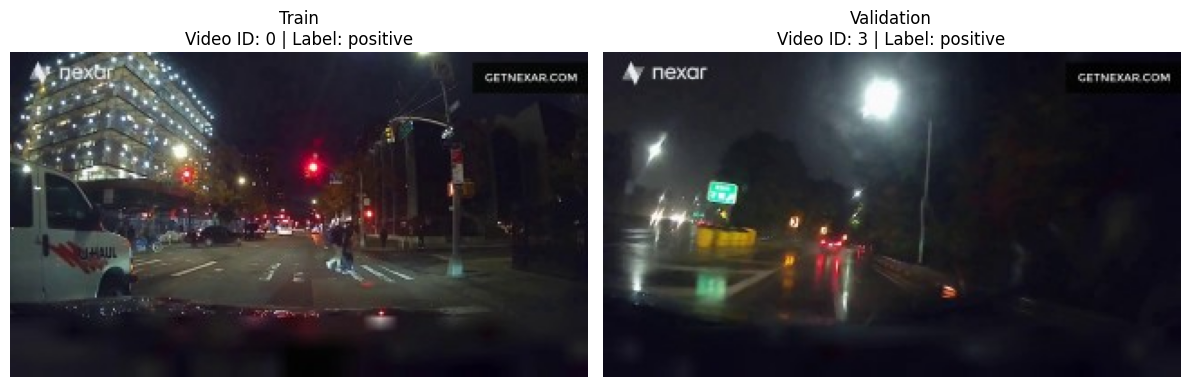

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

samples = [
    ("Train", train_df.iloc[0]),
    ("Validation", val_df.iloc[0]),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for axis, (split_name, row) in zip(axes, samples):
    image = Image.open(row["frame_path"]).convert("RGB")

    axis.imshow(image)
    axis.set_title(
        f"{split_name}\n"
        f"Video ID: {row['video_id']} | Label: {row['label']}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## ۷. تعریف پیش‌پردازش تصاویر

برای مدل پایه از `ResNet18` ازپیش‌آموزش‌دیده روی ImageNet استفاده می‌کنیم.

بنابراین تصاویر با میانگین و انحراف معیار ImageNet نرمال‌سازی می‌شوند تا ورودی با داده‌ای که مدل قبلاً روی آن آموزش دیده سازگار باشد.

در نسخه پایه از Data Augmentation استفاده نمی‌کنیم تا یک نتیجه ساده و قابل‌مقایسه داشته باشیم. بعداً می‌توان اثر Augmentation را جداگانه آزمایش کرد.

</div>

In [16]:
from torchvision import transforms

IMAGE_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    ),
])

print("Train transform:")
print(train_transform)

print("\nValidation transform:")
print(val_transform)

Train transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


<div dir="rtl" align="right">

## ۸. بررسی تعداد فریم‌های هر ویدئو

مدل باید از هر ویدئو تعداد ثابتی فریم دریافت کند تا بتوان ویدئوها را در یک Batch قرار داد.

در این مرحله توزیع تعداد فریم‌های هر ویدئو بررسی می‌شود تا تعداد مناسب فریم ورودی بر اساس داده واقعی انتخاب شود، نه به‌صورت حدسی.

</div>

In [17]:
import pandas as pd

train_frame_counts = train_df.groupby("video_id").size()
val_frame_counts = val_df.groupby("video_id").size()

frame_count_summary = pd.DataFrame({
    "train": train_frame_counts.describe(),
    "validation": val_frame_counts.describe(),
})

display(frame_count_summary)

print("Minimum Train frames:", train_frame_counts.min())
print("Maximum Train frames:", train_frame_counts.max())
print("Median Train frames:", int(train_frame_counts.median()))

print("\nMinimum Validation frames:", val_frame_counts.min())
print("Maximum Validation frames:", val_frame_counts.max())
print("Median Validation frames:", int(val_frame_counts.median()))

,train,validation
count,80.000000,20.000000
mean,74.650000,80.900000
std,15.716717,1.372665
min,30.000000,77.000000
25%,79.000000,81.000000
50%,81.000000,81.000000
75%,81.000000,81.250000
max,90.000000,83.000000


Minimum Train frames: 30
Maximum Train frames: 90
Median Train frames: 81

Minimum Validation frames: 77
Maximum Validation frames: 83
Median Validation frames: 81


<div dir="rtl" align="right">

## ۹. انتخاب تعداد فریم ورودی هر ویدئو

برای مدل پایه از هر ویدئو **۱۶ فریم با فاصله یکنواخت** انتخاب می‌کنیم.

دلیل انتخاب:

- تمام ویدئوها حداقل ۳۰ فریم دارند.
- ۱۶ فریم بخش‌های مختلف ویدئو را پوشش می‌دهد.
- نسبت به استفاده از همه فریم‌ها، حافظه و زمان آموزش را کاهش می‌دهد.
- برای یک مدل پایه ساده و قابل‌مقایسه مناسب است.

ترتیب فریم‌ها حفظ می‌شود، اما مدل پایه در ادامه ویژگی آن‌ها را با میانگین‌گیری ترکیب خواهد کرد.

</div>

In [18]:
import numpy as np

NUM_FRAMES = 16

def uniform_sample_indices(total_frames, num_frames=NUM_FRAMES):
    if total_frames < num_frames:
        raise ValueError(
            f"Video has only {total_frames} frames, "
            f"but {num_frames} frames were requested."
        )

    return np.linspace(
        0,
        total_frames - 1,
        num=num_frames,
        dtype=int
    )

sample_video_id = train_df["video_id"].iloc[0]
sample_video_frames = (
    train_df[train_df["video_id"] == sample_video_id]
    .sort_values("frame_index")
    .reset_index(drop=True)
)

sample_indices = uniform_sample_indices(len(sample_video_frames))

print("Video ID:", sample_video_id)
print("Total available frames:", len(sample_video_frames))
print("Selected frame positions:", sample_indices.tolist())
print(
    "Selected original frame indices:",
    sample_video_frames.iloc[sample_indices]["frame_index"].tolist()
)

Video ID: 0
Total available frames: 83
Selected frame positions: [0, 5, 10, 16, 21, 27, 32, 38, 43, 49, 54, 60, 65, 71, 76, 82]
Selected original frame indices: [0, 5, 10, 16, 21, 27, 32, 38, 43, 49, 54, 60, 65, 71, 76, 82]


<div dir="rtl" align="right">

## ۱۰. ساخت Dataset ویدئویی

در این مرحله یک `Dataset` سفارشی ساخته می‌شود که برای هر ویدئو:

- فریم‌ها را بر اساس زمان مرتب می‌کند.
- ۱۶ فریم با فاصله یکنواخت انتخاب می‌کند.
- تصاویر را پیش‌پردازش می‌کند.
- برچسب‌ها را به عدد تبدیل می‌کند:
  - `negative = 0`
  - `positive = 1`

خروجی هر نمونه به شکل زیر خواهد بود:

`Frames × Channels × Height × Width`

</div>

In [19]:
from torch.utils.data import Dataset
from PIL import Image
import torch

LABEL_MAP = {
    "negative": 0,
    "positive": 1,
}


class CollisionVideoDataset(Dataset):
    def __init__(self, dataframe, transform, num_frames=16):
        self.transform = transform
        self.num_frames = num_frames

        self.video_groups = [
            group.sort_values("frame_index").reset_index(drop=True)
            for _, group in dataframe.groupby("video_id", sort=True)
        ]

    def __len__(self):
        return len(self.video_groups)

    def __getitem__(self, index):
        video_df = self.video_groups[index]

        selected_positions = uniform_sample_indices(
            total_frames=len(video_df),
            num_frames=self.num_frames
        )

        frames = []

        for position in selected_positions:
            frame_path = video_df.iloc[position]["frame_path"]

            with Image.open(frame_path) as image:
                image = image.convert("RGB")
                image = self.transform(image)

            frames.append(image)

        frames = torch.stack(frames)

        label_name = video_df.iloc[0]["label"]
        label = torch.tensor(LABEL_MAP[label_name], dtype=torch.long)

        video_id = str(int(video_df.iloc[0]["video_id"])).zfill(5)

        return {
            "frames": frames,
            "label": label,
            "video_id": video_id,
        }


train_dataset = CollisionVideoDataset(
    dataframe=train_df,
    transform=train_transform,
    num_frames=NUM_FRAMES
)

val_dataset = CollisionVideoDataset(
    dataframe=val_df,
    transform=val_transform,
    num_frames=NUM_FRAMES
)

sample = train_dataset[0]

print("Train videos:", len(train_dataset))
print("Validation videos:", len(val_dataset))
print("Frames shape:", sample["frames"].shape)
print("Label:", sample["label"].item())
print("Video ID:", sample["video_id"])

Train videos: 80
Validation videos: 20
Frames shape: torch.Size([16, 3, 224, 224])
Label: 1
Video ID: 00000


<div dir="rtl" align="right">

## ۱۱. ساخت DataLoader و بررسی Batch

در این مرحله `DataLoader` ساخته می‌شود تا چند ویدئو به‌صورت یک Batch به مدل داده شوند.

تنظیمات:

- اندازه Batch برابر ۴
- Shuffle فقط برای داده‌های آموزش
- استفاده از `pin_memory` هنگام اجرای GPU

شکل ورودی مدل باید به‌صورت زیر باشد:

`Batch × Frames × Channels × Height × Width`

</div>

In [20]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

batch = next(iter(train_loader))

print("Frames batch shape:", batch["frames"].shape)
print("Labels shape:", batch["label"].shape)
print("Video IDs:", batch["video_id"])
print("Labels:", batch["label"].tolist())
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Frames batch shape: torch.Size([4, 16, 3, 224, 224])
Labels shape: torch.Size([4])
Video IDs: ['01052', '01096', '00014', '00062']
Labels: [0, 0, 1, 1]
Train batches: 20
Validation batches: 5


<div dir="rtl" align="right">

## ۱۲. تعریف معماری مدل پایه

معماری مدل پایه:

`۱۶ فریم → ResNet18 → میانگین ویژگی‌ها → طبقه‌بندی دودویی`

در این نسخه:

- از وزن‌های ازپیش‌آموزش‌دیده `ResNet18` استفاده می‌کنیم.
- لایه‌های ResNet ثابت می‌مانند و فقط طبقه‌بند نهایی آموزش می‌بیند.
- از هر فریم یک بردار ویژگی استخراج می‌شود.
- میانگین ۱۶ بردار، نماینده کل ویدئو خواهد بود.
- خروجی مدل دو Logit برای کلاس‌های تصادف و عدم تصادف است.

این روش به‌عنوان Baseline انتخاب شده چون ساده، سریع و قابل توضیح است. بعداً می‌توان Fine-tuning را به‌عنوان روش جایگزین آزمایش کرد.

</div>

In [21]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


class BaselineCollisionModel(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()

        # ResNet18 ازپیش‌آموزش‌دیده
        backbone = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()

        # ثابت‌کردن Feature Extractor
        for parameter in backbone.parameters():
            parameter.requires_grad = False

        self.backbone = backbone

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes)
        )

    def train(self, mode=True):
        super().train(mode)

        # جلوگیری از تغییر آمار BatchNorm در Backbone ثابت
        self.backbone.eval()

        return self

    def forward(self, frames):
        batch_size, num_frames, channels, height, width = frames.shape

        frames = frames.reshape(
            batch_size * num_frames,
            channels,
            height,
            width
        )

        # استخراج ویژگی هر فریم بدون محاسبه Gradient
        with torch.no_grad():
            frame_features = self.backbone(frames)

        frame_features = frame_features.reshape(
            batch_size,
            num_frames,
            -1
        )

        # ترکیب ویژگی فریم‌ها در سطح ویدئو
        video_features = frame_features.mean(dim=1)

        logits = self.classifier(video_features)

        return logits


model = BaselineCollisionModel().to(DEVICE)

test_frames = batch["frames"].to(DEVICE)
test_logits = model(test_frames)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Input shape:", test_frames.shape)
print("Output shape:", test_logits.shape)
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]


Input shape: torch.Size([4, 16, 3, 224, 224])
Output shape: torch.Size([4, 2])
Total parameters: 11,177,538
Trainable parameters: 1,026


<div dir="rtl" align="right">

## ۱۳. تعریف تابع خطا و بهینه‌ساز

برای طبقه‌بندی دوکلاسه از `CrossEntropyLoss` استفاده می‌کنیم؛ زیرا خروجی مدل دو Logit خام است و برچسب‌ها به‌صورت صفر و یک تعریف شده‌اند.

به‌دلیل تقریباً متوازن بودن کلاس‌های Train، فعلاً از وزن‌دهی کلاس‌ها استفاده نمی‌کنیم.

برای آموزش طبقه‌بند نهایی از `AdamW` استفاده می‌شود؛ چون فقط تعداد کمی پارامتر آموزش‌پذیر داریم و این روش برای شروع پایدار و ساده است.

تنظیمات اولیه:

- نرخ یادگیری: `0.001`
- وزن منظم‌سازی: `0.0001`
- تعداد Epoch: `10`

</div>

In [25]:
import torch.optim as optim

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 10

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Epochs:", NUM_EPOCHS)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 0.0001
Epochs: 10


<div dir="rtl" align="right">

## ۱۴. آموزش مدل پایه با DataLoader اصلاح‌شده

به‌دلیل ناسازگاری پردازش چندگانه با Google Drive، تعداد Workerها روی صفر قرار گرفت.

مدل و بهینه‌ساز از ابتدا ساخته می‌شوند تا هیچ به‌روزرسانی ناقصی از اجرای متوقف‌شده باقی نماند. پیشرفت پردازش Batchهای هر دوره نیز نمایش داده می‌شود.

بهترین مدل بر اساس `Validation F1` در مسیر زیر ذخیره خواهد شد:

`models/cv/baseline_model.pth`

</div>

In [26]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import pandas as pd
import torch.optim as optim

# شروع کاملاً مجدد آموزش
model = BaselineCollisionModel().to(DEVICE)

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

criterion = nn.CrossEntropyLoss()


def run_epoch(model, data_loader, criterion, epoch, phase, optimizer=None):
    is_training = optimizer is not None

    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    progress_bar = tqdm(
        data_loader,
        desc=f"Epoch {epoch:02d} - {phase}",
        leave=False
    )

    for batch in progress_bar:
        frames = batch["frames"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(frames)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        all_labels.extend(labels.detach().cpu().tolist())
        all_predictions.extend(predictions.detach().cpu().tolist())

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    return {
        "loss": total_loss / len(data_loader.dataset),
        "accuracy": accuracy_score(all_labels, all_predictions),
        "f1": f1_score(
            all_labels,
            all_predictions,
            pos_label=1,
            zero_division=0
        ),
    }


MODEL_PATH = CV_MODEL_DIR / "baseline_model.pth"
HISTORY_PATH = CV_OUTPUT_DIR / "baseline_training_history.csv"

history = []
best_val_f1 = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = run_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        epoch=epoch,
        phase="Train"
    )

    val_metrics = run_epoch(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        epoch=epoch,
        phase="Validation"
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]

        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "validation_metrics": val_metrics,
            "num_frames": NUM_FRAMES,
            "image_size": IMAGE_SIZE,
            "label_map": LABEL_MAP,
        }, MODEL_PATH)

history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

print("\nBest Validation F1:", round(best_val_f1, 4))
print("Saved model:", MODEL_PATH)
print("Saved history:", HISTORY_PATH)

Epoch 01 - Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.7983 | Train Acc: 0.5375 | Train F1: 0.5316 | Val Loss: 0.7165 | Val Acc: 0.5000 | Val F1: 0.1667


Epoch 02 - Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 02 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 09 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.5585 | Train Acc: 0.7000 | Train F1: 0.7209 | Val Loss: 0.6460 | Val Acc: 0.5500 | Val F1: 0.3077


Epoch 10 - Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 10 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.6072 | Train Acc: 0.6750 | Train F1: 0.6579 | Val Loss: 0.5483 | Val Acc: 0.7500 | Val F1: 0.7368

Best Validation F1: 0.8182
Saved model: /content/drive/MyDrive/AI_Project2/models/cv/baseline_model.pth
Saved history: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_training_history.csv


<div dir="rtl" align="right">

## ۱۵. تولید پیش‌بینی‌های Validation

بهترین Checkpoint ذخیره‌شده بارگذاری می‌شود و برای هر ویدئوی Validation موارد زیر ثبت می‌شوند:

- شناسه ویدئو
- برچسب واقعی
- برچسب پیش‌بینی‌شده
- احتمال تعلق به کلاس تصادف

نتیجه در فایل زیر ذخیره می‌شود:

`outputs/cv/baseline_validation_predictions.csv`

</div>

In [27]:
import torch
import pandas as pd

PREDICTIONS_PATH = (
    CV_OUTPUT_DIR / "baseline_validation_predictions.csv"
)

ID_TO_LABEL = {
    0: "negative",
    1: "positive",
}

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

prediction_records = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Validation prediction"):
        frames = batch["frames"].to(
            DEVICE,
            non_blocking=True
        )

        logits = model(frames)
        probabilities = torch.softmax(logits, dim=1)

        predicted_ids = probabilities.argmax(dim=1)
        positive_probabilities = probabilities[:, 1]

        for video_id, true_id, predicted_id, positive_probability in zip(
            batch["video_id"],
            batch["label"].tolist(),
            predicted_ids.cpu().tolist(),
            positive_probabilities.cpu().tolist()
        ):
            prediction_records.append({
                "video_id": video_id,
                "true_label": ID_TO_LABEL[true_id],
                "predicted_label": ID_TO_LABEL[predicted_id],
                "predicted_probability": positive_probability,
            })

predictions_df = pd.DataFrame(prediction_records)

assert len(predictions_df) == len(val_dataset)
assert predictions_df["video_id"].is_unique

predictions_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print("Best checkpoint epoch:", checkpoint["epoch"])
print(
    "Checkpoint validation metrics:",
    checkpoint["validation_metrics"]
)
print("Number of predictions:", len(predictions_df))
print("Saved predictions:", PREDICTIONS_PATH)

display(predictions_df.head())

Validation prediction:   0%|          | 0/5 [00:00<?, ?it/s]

Best checkpoint epoch: 6
Checkpoint validation metrics: {'loss': 0.5688163936138153, 'accuracy': 0.8, 'f1': 0.8181818181818182}
Number of predictions: 20
Saved predictions: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_validation_predictions.csv


,video_id,true_label,predicted_label,predicted_probability
0,00003,positive,positive,0.570595
1,00008,positive,positive,0.615804
2,00010,positive,positive,0.506100
3,00013,positive,positive,0.720241
4,00018,positive,positive,0.597453


<div dir="rtl" align="right">

## ۱۶. ارزیابی مدل پایه روی Validation

در این مرحله معیارهای زیر محاسبه می‌شوند:

- Accuracy
- Precision
- Recall
- F1-score
- تعداد False Positive و False Negative
- ماتریس درهم‌ریختگی

کلاس `positive` به‌عنوان کلاس تصادف در نظر گرفته می‌شود.

نتایج در فایل‌های زیر ذخیره خواهند شد:

- `outputs/cv/baseline_validation_metrics.csv`
- `outputs/cv/baseline_confusion_matrix.png`

با توجه به اینکه مجموعه Validation فقط شامل ۲۰ ویدئو است، تغییر پیش‌بینی چند نمونه می‌تواند معیارها را به‌طور محسوسی تغییر دهد.

</div>

,model,validation_samples,accuracy,precision,recall,f1_score,true_negative,false_positive,false_negative,true_positive
0,baseline_resnet18_mean_pooling,20,0.8,0.75,0.9,0.818182,7,3,1,9


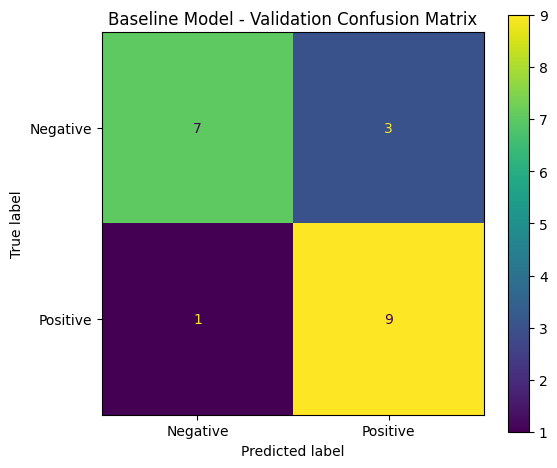

Saved metrics: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_validation_metrics.csv
Saved confusion matrix: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_confusion_matrix.png


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import pandas as pd

METRICS_PATH = CV_OUTPUT_DIR / "baseline_validation_metrics.csv"
CONFUSION_MATRIX_PATH = CV_OUTPUT_DIR / "baseline_confusion_matrix.png"

y_true = predictions_df["true_label"].map(LABEL_MAP)
y_pred = predictions_df["predicted_label"].map(LABEL_MAP)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)
recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)
f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

metrics_df = pd.DataFrame([{
    "model": "baseline_resnet18_mean_pooling",
    "validation_samples": len(predictions_df),
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "true_negative": tn,
    "false_positive": fp,
    "false_negative": fn,
    "true_positive": tp,
}])

metrics_df.to_csv(METRICS_PATH, index=False)

display(metrics_df)

display_labels = ["Negative", "Positive"]

figure, axis = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
).plot(
    ax=axis,
    values_format="d"
)

axis.set_title("Baseline Model - Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Saved metrics:", METRICS_PATH)
print("Saved confusion matrix:", CONFUSION_MATRIX_PATH)

<div dir="rtl" align="right">

## ۱۷. تحلیل False Positive و False Negative

در این مرحله نمونه‌هایی که مدل اشتباه پیش‌بینی کرده استخراج می‌شوند.

دو نوع خطا بررسی می‌شود:

- **False Positive:** ویدئوی بدون تصادف که تصادف تشخیص داده شده است.
- **False Negative:** ویدئوی تصادف که بدون تصادف تشخیص داده شده است.

در مسئله تشخیص تصادف، False Negative اهمیت بیشتری دارد؛ زیرا یک تصادف واقعی توسط مدل شناسایی نشده است.

نتایج در فایل زیر ذخیره می‌شوند:

`outputs/cv/baseline_validation_errors.csv`

</div>

In [29]:
ERRORS_PATH = CV_OUTPUT_DIR / "baseline_validation_errors.csv"

errors_df = predictions_df[
    predictions_df["true_label"]
    != predictions_df["predicted_label"]
].copy()

errors_df["error_type"] = errors_df.apply(
    lambda row: (
        "False Positive"
        if row["true_label"] == "negative"
        else "False Negative"
    ),
    axis=1
)

errors_df["prediction_confidence"] = errors_df.apply(
    lambda row: (
        row["predicted_probability"]
        if row["predicted_label"] == "positive"
        else 1 - row["predicted_probability"]
    ),
    axis=1
)

errors_df = errors_df[
    [
        "video_id",
        "true_label",
        "predicted_label",
        "predicted_probability",
        "prediction_confidence",
        "error_type",
    ]
].sort_values(
    "prediction_confidence",
    ascending=False
).reset_index(drop=True)

errors_df.to_csv(ERRORS_PATH, index=False)

print("Total errors:", len(errors_df))
print(
    "False Positives:",
    (errors_df["error_type"] == "False Positive").sum()
)
print(
    "False Negatives:",
    (errors_df["error_type"] == "False Negative").sum()
)
print("Saved errors:", ERRORS_PATH)

display(errors_df)

Total errors: 4
False Positives: 3
False Negatives: 1
Saved errors: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_validation_errors.csv


,video_id,true_label,predicted_label,predicted_probability,prediction_confidence,error_type
0,01081,negative,positive,0.711947,0.711947,False Positive
1,01116,negative,positive,0.614347,0.614347,False Positive
2,01103,negative,positive,0.580255,0.580255,False Positive
3,00037,positive,negative,0.495432,0.504568,False Negative


<div dir="rtl" align="right">

## ۱۸. آماده‌سازی نسخه Fine-tuned مدل پایه

برای اینکه اثر Fine-tuning را منصفانه بررسی کنیم، موارد زیر ثابت می‌مانند:

- همان ۸۰ ویدئوی Train و ۲۰ ویدئوی Validation
- همان ۱۶ فریم از هر ویدئو
- همان پیش‌پردازش
- همان طبقه‌بند و معیار انتخاب مدل

مدل از بهترین Checkpoint قبلی شروع می‌کند. لایه‌های ابتدایی ResNet18 ثابت می‌مانند و فقط `layer4` و طبقه‌بند نهایی آموزش داده می‌شوند.

برای جلوگیری از تغییر شدید وزن‌های ازپیش‌آموزش‌دیده، نرخ یادگیری `layer4` بسیار کمتر از نرخ یادگیری طبقه‌بند در نظر گرفته می‌شود.

</div>

In [30]:
class FineTunedCollisionModel(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()

        backbone = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()

        # ابتدا تمام ResNet ثابت می‌شود
        for parameter in backbone.parameters():
            parameter.requires_grad = False

        # فقط آخرین بخش ResNet آزاد می‌شود
        for parameter in backbone.layer4.parameters():
            parameter.requires_grad = True

        self.backbone = backbone

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes)
        )

    def train(self, mode=True):
        super().train(mode)

        if mode:
            # بخش‌های ثابت در حالت Evaluation باقی می‌مانند
            self.backbone.eval()

            # فقط layer4 وارد حالت آموزش می‌شود
            self.backbone.layer4.train()

            # آمار BatchNorm ثابت می‌ماند تا روی داده کم ناپایدار نشود
            for module in self.backbone.modules():
                if isinstance(module, nn.BatchNorm2d):
                    module.eval()

        return self

    def forward(self, frames):
        batch_size, num_frames, channels, height, width = frames.shape

        frames = frames.reshape(
            batch_size * num_frames,
            channels,
            height,
            width
        )

        frame_features = self.backbone(frames)

        frame_features = frame_features.reshape(
            batch_size,
            num_frames,
            -1
        )

        video_features = frame_features.mean(dim=1)

        return self.classifier(video_features)


fine_tuned_model = FineTunedCollisionModel().to(DEVICE)

# شروع از بهترین مدل پایه قبلی
baseline_checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

fine_tuned_model.load_state_dict(
    baseline_checkpoint["model_state_dict"]
)

BACKBONE_LR = 1e-5
CLASSIFIER_LR = 1e-3

fine_tuned_optimizer = optim.AdamW(
    [
        {
            "params": fine_tuned_model.backbone.layer4.parameters(),
            "lr": BACKBONE_LR,
        },
        {
            "params": fine_tuned_model.classifier.parameters(),
            "lr": CLASSIFIER_LR,
        },
    ],
    weight_decay=WEIGHT_DECAY
)

total_parameters = sum(
    parameter.numel()
    for parameter in fine_tuned_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in fine_tuned_model.parameters()
    if parameter.requires_grad
)

print("Loaded baseline epoch:", baseline_checkpoint["epoch"])
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print("Layer4 learning rate:", BACKBONE_LR)
print("Classifier learning rate:", CLASSIFIER_LR)

Loaded baseline epoch: 6
Total parameters: 11,177,538
Trainable parameters: 8,394,754
Layer4 learning rate: 1e-05
Classifier learning rate: 0.001


<div dir="rtl" align="right">

## ۱۹. آموزش نسخه Fine-tuned

نسخه Fine-tuned حداکثر برای ۸ دوره آموزش داده می‌شود.

برای کاهش خطر بیش‌برازش:

- نرخ یادگیری `layer4` برابر `0.00001` است.
- چون طبقه‌بند قبلاً آموزش دیده، نرخ یادگیری آن به `0.0001` کاهش می‌یابد.
- اگر F1 اعتبارسنجی برای سه دوره بهتر نشود، آموزش متوقف می‌شود.
- مدل پایه اولیه نیز به‌عنوان Epoch صفر نگهداری می‌شود؛ بنابراین نسخه ضعیف‌تر جای مدل قبلی را نمی‌گیرد.

خروجی‌ها جدا از مدل پایه ذخیره می‌شوند.

</div>

In [31]:
MAX_FINE_TUNE_EPOCHS = 8
PATIENCE = 3

FINETUNED_MODEL_PATH = (
    CV_MODEL_DIR / "baseline_finetuned_model.pth"
)
FINETUNED_HISTORY_PATH = (
    CV_OUTPUT_DIR / "baseline_finetuned_training_history.csv"
)

# نرخ کمتر برای طبقه‌بندی که قبلاً آموزش دیده است
fine_tuned_optimizer = optim.AdamW(
    [
        {
            "params": fine_tuned_model.backbone.layer4.parameters(),
            "lr": 1e-5,
        },
        {
            "params": fine_tuned_model.classifier.parameters(),
            "lr": 1e-4,
        },
    ],
    weight_decay=WEIGHT_DECAY
)

baseline_val_metrics = baseline_checkpoint["validation_metrics"]
best_val_f1 = baseline_val_metrics["f1"]
best_epoch = 0
epochs_without_improvement = 0

fine_tuned_history = []

# ذخیره نقطه شروع؛ معادل بهترین مدل پایه
torch.save(
    {
        "model_state_dict": fine_tuned_model.state_dict(),
        "epoch": 0,
        "validation_metrics": baseline_val_metrics,
        "num_frames": NUM_FRAMES,
        "image_size": IMAGE_SIZE,
        "label_map": LABEL_MAP,
    },
    FINETUNED_MODEL_PATH
)

for epoch in range(1, MAX_FINE_TUNE_EPOCHS + 1):
    train_metrics = run_epoch(
        model=fine_tuned_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=fine_tuned_optimizer,
        epoch=epoch,
        phase="Fine-tune Train"
    )

    val_metrics = run_epoch(
        model=fine_tuned_model,
        data_loader=val_loader,
        criterion=criterion,
        epoch=epoch,
        phase="Fine-tune Validation"
    )

    fine_tuned_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
    })

    print(
        f"Epoch {epoch:02d}/{MAX_FINE_TUNE_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": fine_tuned_model.state_dict(),
                "epoch": epoch,
                "validation_metrics": val_metrics,
                "num_frames": NUM_FRAMES,
                "image_size": IMAGE_SIZE,
                "label_map": LABEL_MAP,
            },
            FINETUNED_MODEL_PATH
        )
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch}: "
            f"Validation F1 did not improve for {PATIENCE} epochs."
        )
        break

fine_tuned_history_df = pd.DataFrame(fine_tuned_history)
fine_tuned_history_df.to_csv(
    FINETUNED_HISTORY_PATH,
    index=False
)

print("\nBaseline Validation F1:", round(
    baseline_val_metrics["f1"], 4
))
print("Best Fine-tuned Validation F1:", round(best_val_f1, 4))
print("Best Fine-tuned epoch:", best_epoch)
print("Saved model:", FINETUNED_MODEL_PATH)
print("Saved history:", FINETUNED_HISTORY_PATH)

Epoch 01 - Fine-tune Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01 - Fine-tune Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 01/8 | Train Loss: 0.6395 | Train Acc: 0.6000 | Train F1: 0.6000 | Val Loss: 0.5806 | Val Acc: 0.7000 | Val F1: 0.6667


Epoch 02 - Fine-tune Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 02 - Fine-tune Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 02/8 | Train Loss: 0.4962 | Train Acc: 0.8000 | Train F1: 0.8095 | Val Loss: 0.5541 | Val Acc: 0.7500 | Val F1: 0.7368


Epoch 03 - Fine-tune Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 03 - Fine-tune Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 03/8 | Train Loss: 0.4829 | Train Acc: 0.7375 | Train F1: 0.7407 | Val Loss: 0.5527 | Val Acc: 0.7500 | Val F1: 0.7619

Early stopping at epoch 3: Validation F1 did not improve for 3 epochs.

Baseline Validation F1: 0.8182
Best Fine-tuned Validation F1: 0.8182
Best Fine-tuned epoch: 0
Saved model: /content/drive/MyDrive/AI_Project2/models/cv/baseline_finetuned_model.pth
Saved history: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_finetuned_training_history.csv


<div dir="rtl" align="right">

## ۲۰. اضافه‌کردن Data Augmentation محدود

با توجه به کم‌بودن تعداد ویدئوهای آموزش، آزادکردن میلیون‌ها پارامتر باعث بهبود مدل نشد.

در آزمایش بعدی ResNet18 دوباره ثابت نگه داشته می‌شود، اما تصاویر Train با تغییرات محدود زیر وارد مدل خواهند شد:

- وارونگی افقی تصادفی
- تغییر جزئی روشنایی و کنتراست
- تغییر جزئی اشباع رنگ

این تغییرات فقط روی Train اعمال می‌شوند و تصاویر Validation بدون تغییر باقی می‌مانند.

</div>

In [32]:
augmented_train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    ),
])

augmented_train_dataset = CollisionVideoDataset(
    dataframe=train_df,
    transform=augmented_train_transform,
    num_frames=NUM_FRAMES
)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

augmented_batch = next(iter(augmented_train_loader))

print("Augmented frames shape:", augmented_batch["frames"].shape)
print("Train videos:", len(augmented_train_dataset))
print("Train batches:", len(augmented_train_loader))
print("\nAugmented transform:")
print(augmented_train_transform)

Augmented frames shape: torch.Size([4, 16, 3, 224, 224])
Train videos: 80
Train batches: 20

Augmented transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


<div dir="rtl" align="right">

## ۲۱. آموزش مدل پایه با Data Augmentation

برای مقایسه منصفانه با مدل پایه قبلی:

- معماری ResNet18 ثابت می‌ماند.
- فقط طبقه‌بند نهایی آموزش می‌بیند.
- تعداد فریم‌ها، Batch Size و تعداد Epochها تغییر نمی‌کنند.
- تنها تفاوت، اعمال Data Augmentation روی تصاویر Train است.

بهترین مدل بر اساس F1 اعتبارسنجی در فایل جداگانه ذخیره می‌شود.

</div>

In [33]:
# بازنشانی Seed برای تکرارپذیری بهتر آزمایش
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# مدل تازه؛ بدون استفاده از طبقه‌بند آموزش‌دیده قبلی
augmented_model = BaselineCollisionModel().to(DEVICE)

augmented_optimizer = optim.AdamW(
    augmented_model.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

AUGMENTED_MODEL_PATH = (
    CV_MODEL_DIR / "baseline_augmented_model.pth"
)

AUGMENTED_HISTORY_PATH = (
    CV_OUTPUT_DIR / "baseline_augmented_training_history.csv"
)

augmented_history = []
best_augmented_f1 = -1.0
best_augmented_epoch = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = run_epoch(
        model=augmented_model,
        data_loader=augmented_train_loader,
        criterion=criterion,
        optimizer=augmented_optimizer,
        epoch=epoch,
        phase="Augmented Train"
    )

    val_metrics = run_epoch(
        model=augmented_model,
        data_loader=val_loader,
        criterion=criterion,
        epoch=epoch,
        phase="Validation"
    )

    augmented_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_augmented_f1:
        best_augmented_f1 = val_metrics["f1"]
        best_augmented_epoch = epoch

        torch.save({
            "model_state_dict": augmented_model.state_dict(),
            "epoch": epoch,
            "validation_metrics": val_metrics,
            "num_frames": NUM_FRAMES,
            "image_size": IMAGE_SIZE,
            "label_map": LABEL_MAP,
            "augmentation": True,
        }, AUGMENTED_MODEL_PATH)

augmented_history_df = pd.DataFrame(augmented_history)

augmented_history_df.to_csv(
    AUGMENTED_HISTORY_PATH,
    index=False
)

print("\nOriginal Baseline F1:", round(
    baseline_checkpoint["validation_metrics"]["f1"], 4
))
print("Best Augmented F1:", round(best_augmented_f1, 4))
print("Best Augmented Epoch:", best_augmented_epoch)
print("Saved model:", AUGMENTED_MODEL_PATH)
print("Saved history:", AUGMENTED_HISTORY_PATH)

Epoch 01 - Augmented Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.8651 | Train Acc: 0.5375 | Train F1: 0.5316 | Val Loss: 0.8237 | Val Acc: 0.4000 | Val F1: 0.0000


Epoch 02 - Augmented Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 02 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 09 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.6270 | Train Acc: 0.6250 | Train F1: 0.5833 | Val Loss: 0.6469 | Val Acc: 0.6000 | Val F1: 0.6923


Epoch 10 - Augmented Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 10 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.7032 | Train Acc: 0.5500 | Train F1: 0.5909 | Val Loss: 0.6735 | Val Acc: 0.5000 | Val F1: 0.2857

Original Baseline F1: 0.8182
Best Augmented F1: 0.6923
Best Augmented Epoch: 9
Saved model: /content/drive/MyDrive/AI_Project2/models/cv/baseline_augmented_model.pth
Saved history: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_augmented_training_history.csv


<div dir="rtl" align="right">

## ۲۲. تعریف مدل با ترکیب Mean و Max Pooling

در مدل پایه، ویژگی‌های ۱۶ فریم فقط میانگین گرفته می‌شدند. این کار ممکن است ویژگی مهم یک فریم، مانند لحظه تصادف، را در میان سایر فریم‌ها کم‌رنگ کند.

در نسخه جدید:

- Mean Pooling اطلاعات کلی ویدئو را نگه می‌دارد.
- Max Pooling برجسته‌ترین ویژگی مشاهده‌شده در فریم‌ها را نگه می‌دارد.
- خروجی این دو روش به هم متصل می‌شود.
- ResNet18 همچنان ثابت می‌ماند تا خطر بیش‌برازش افزایش پیدا نکند.

تنها تفاوت این آزمایش با مدل پایه، روش ترکیب ویژگی‌های فریم‌ها است.

</div>

In [35]:
class MeanMaxCollisionModel(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()

        backbone = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()

        # ثابت نگه‌داشتن کل ResNet18
        for parameter in backbone.parameters():
            parameter.requires_grad = False

        self.backbone = backbone

        # Mean و Max هرکدام 512 ویژگی دارند
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim * 2, num_classes)
        )

    def train(self, mode=True):
        super().train(mode)

        # Backbone ثابت است و BatchNorm نباید تغییر کند
        self.backbone.eval()

        return self

    def forward(self, frames):
        batch_size, num_frames, channels, height, width = frames.shape

        frames = frames.reshape(
            batch_size * num_frames,
            channels,
            height,
            width
        )

        with torch.no_grad():
            frame_features = self.backbone(frames)

        frame_features = frame_features.reshape(
            batch_size,
            num_frames,
            -1
        )

        mean_features = frame_features.mean(dim=1)
        max_features = frame_features.max(dim=1).values

        video_features = torch.cat(
            [mean_features, max_features],
            dim=1
        )

        return self.classifier(video_features)


mean_max_model = MeanMaxCollisionModel().to(DEVICE)

test_logits = mean_max_model(
    batch["frames"].to(DEVICE)
)

total_parameters = sum(
    parameter.numel()
    for parameter in mean_max_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in mean_max_model.parameters()
    if parameter.requires_grad
)

print("Input shape:", batch["frames"].shape)
print("Output shape:", test_logits.shape)
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")

Input shape: torch.Size([4, 16, 3, 224, 224])
Output shape: torch.Size([4, 2])
Total parameters: 11,178,562
Trainable parameters: 2,050


<div dir="rtl" align="right">

## ۲۳. آموزش مدل Mean-Max Pooling

در این آزمایش همان تنظیمات مدل پایه حفظ می‌شوند:

- همان داده‌های Train و Validation
- همان ۱۶ فریم
- همان ResNet18 ثابت
- همان نرخ یادگیری و تعداد Epochها

تنها تفاوت، استفاده هم‌زمان از میانگین و بیشینه ویژگی‌های فریم‌ها است. بهترین مدل بر اساس F1 اعتبارسنجی ذخیره می‌شود.

</div>

In [36]:
# بازنشانی Seed برای مقایسه تکرارپذیر
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# مدل تازه
mean_max_model = MeanMaxCollisionModel().to(DEVICE)

mean_max_optimizer = optim.AdamW(
    mean_max_model.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

MEAN_MAX_MODEL_PATH = (
    CV_MODEL_DIR / "baseline_mean_max_model.pth"
)

MEAN_MAX_HISTORY_PATH = (
    CV_OUTPUT_DIR / "baseline_mean_max_training_history.csv"
)

mean_max_history = []
best_mean_max_f1 = -1.0
best_mean_max_epoch = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = run_epoch(
        model=mean_max_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=mean_max_optimizer,
        epoch=epoch,
        phase="Mean-Max Train"
    )

    val_metrics = run_epoch(
        model=mean_max_model,
        data_loader=val_loader,
        criterion=criterion,
        epoch=epoch,
        phase="Validation"
    )

    mean_max_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_mean_max_f1:
        best_mean_max_f1 = val_metrics["f1"]
        best_mean_max_epoch = epoch

        torch.save({
            "model_state_dict": mean_max_model.state_dict(),
            "epoch": epoch,
            "validation_metrics": val_metrics,
            "num_frames": NUM_FRAMES,
            "image_size": IMAGE_SIZE,
            "label_map": LABEL_MAP,
            "pooling": "mean_max",
        }, MEAN_MAX_MODEL_PATH)

mean_max_history_df = pd.DataFrame(mean_max_history)

mean_max_history_df.to_csv(
    MEAN_MAX_HISTORY_PATH,
    index=False
)

print("\nOriginal Baseline F1:", round(
    baseline_checkpoint["validation_metrics"]["f1"], 4
))
print("Best Mean-Max F1:", round(best_mean_max_f1, 4))
print("Best Mean-Max Epoch:", best_mean_max_epoch)
print("Saved model:", MEAN_MAX_MODEL_PATH)
print("Saved history:", MEAN_MAX_HISTORY_PATH)

Epoch 01 - Mean-Max Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.9380 | Train Acc: 0.5750 | Train F1: 0.5405 | Val Loss: 0.9966 | Val Acc: 0.5000 | Val F1: 0.0000


Epoch 02 - Mean-Max Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 02 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 09 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.4947 | Train Acc: 0.7750 | Train F1: 0.7805 | Val Loss: 0.5054 | Val Acc: 0.7500 | Val F1: 0.7368


Epoch 10 - Mean-Max Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 10 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.3893 | Train Acc: 0.8250 | Train F1: 0.8108 | Val Loss: 0.7246 | Val Acc: 0.6000 | Val F1: 0.7143

Original Baseline F1: 0.8182
Best Mean-Max F1: 0.8
Best Mean-Max Epoch: 8
Saved model: /content/drive/MyDrive/AI_Project2/models/cv/baseline_mean_max_model.pth
Saved history: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_mean_max_training_history.csv


<div dir="rtl" align="right">

## ۲۴. نمونه‌گیری زمانی تصادفی از فریم‌ها

در مدل‌های قبلی، از هر ویدئو همیشه ۱۶ فریم ثابت و یکنواخت انتخاب می‌شدند. بنابراین مدل در تمام Epochها تصاویر یکسانی را مشاهده می‌کرد.

در این آزمایش، ویدئو به ۱۶ بخش زمانی تقسیم می‌شود و در هر بار خواندن داده، یک فریم تصادفی از هر بخش انتخاب خواهد شد.

مزیت این روش:

- در طول آموزش فریم‌های بیشتری از هر ویدئو دیده می‌شوند.
- ترتیب زمانی و پوشش کل ویدئو حفظ می‌شود.
- برخلاف تغییر رنگ و نور، محتوای واقعی تصاویر دست‌کاری نمی‌شود.
- Validation همچنان ثابت باقی می‌ماند تا مقایسه منصفانه باشد.

</div>

In [37]:
def random_segment_sample_indices(total_frames, num_frames=NUM_FRAMES):
    if total_frames < num_frames:
        raise ValueError(
            f"Video has only {total_frames} frames, "
            f"but {num_frames} frames were requested."
        )

    boundaries = np.linspace(
        0,
        total_frames,
        num=num_frames + 1,
        dtype=int
    )

    selected_indices = []

    for start, end in zip(boundaries[:-1], boundaries[1:]):
        selected_index = np.random.randint(start, end)
        selected_indices.append(selected_index)

    return np.array(selected_indices)


class RandomTemporalCollisionDataset(CollisionVideoDataset):
    def __getitem__(self, index):
        video_df = self.video_groups[index]

        selected_positions = random_segment_sample_indices(
            total_frames=len(video_df),
            num_frames=self.num_frames
        )

        frames = []

        for position in selected_positions:
            frame_path = video_df.iloc[position]["frame_path"]

            with Image.open(frame_path) as image:
                image = image.convert("RGB")
                image = self.transform(image)

            frames.append(image)

        frames = torch.stack(frames)

        label_name = video_df.iloc[0]["label"]
        label = torch.tensor(
            LABEL_MAP[label_name],
            dtype=torch.long
        )

        video_id = str(
            int(video_df.iloc[0]["video_id"])
        ).zfill(5)

        return {
            "frames": frames,
            "label": label,
            "video_id": video_id,
        }


random_temporal_train_dataset = RandomTemporalCollisionDataset(
    dataframe=train_df,
    transform=train_transform,
    num_frames=NUM_FRAMES
)

random_temporal_train_loader = DataLoader(
    random_temporal_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

sample_count = len(
    random_temporal_train_dataset.video_groups[0]
)

first_selection = random_segment_sample_indices(sample_count)
second_selection = random_segment_sample_indices(sample_count)

print("Available frames:", sample_count)
print("First selection:", first_selection.tolist())
print("Second selection:", second_selection.tolist())
print(
    "Selections are different:",
    not np.array_equal(first_selection, second_selection)
)

sample_batch = next(iter(random_temporal_train_loader))
print("Batch shape:", sample_batch["frames"].shape)

Available frames: 83
First selection: [3, 9, 12, 19, 24, 26, 33, 38, 43, 50, 54, 59, 66, 68, 75, 82]
Second selection: [1, 8, 14, 15, 23, 26, 35, 39, 41, 46, 53, 59, 63, 70, 75, 82]
Selections are different: True
Batch shape: torch.Size([4, 16, 3, 224, 224])


<div dir="rtl" align="right">

## ۲۵. آموزش مدل با نمونه‌گیری زمانی تصادفی

در این آزمایش معماری و تنظیمات مدل پایه ثابت می‌مانند و تنها روش انتخاب فریم‌های Train تغییر می‌کند.

در هر Epoch، مدل از هر بخش زمانی ویدئو یک فریم متفاوت می‌بیند. بنابراین طی آموزش، تعداد بیشتری از فریم‌های واقعی هر ویدئو استفاده می‌شوند.

Validation همچنان از همان ۱۶ فریم ثابت استفاده می‌کند تا نتیجه با مدل پایه قابل‌مقایسه باشد.

</div>

In [38]:
# بازنشانی Seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# همان معماری اصلی Baseline
random_temporal_model = BaselineCollisionModel().to(DEVICE)

random_temporal_optimizer = optim.AdamW(
    random_temporal_model.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

RANDOM_TEMPORAL_MODEL_PATH = (
    CV_MODEL_DIR / "baseline_random_temporal_model.pth"
)

RANDOM_TEMPORAL_HISTORY_PATH = (
    CV_OUTPUT_DIR / "baseline_random_temporal_training_history.csv"
)

random_temporal_history = []
best_random_temporal_f1 = -1.0
best_random_temporal_epoch = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = run_epoch(
        model=random_temporal_model,
        data_loader=random_temporal_train_loader,
        criterion=criterion,
        optimizer=random_temporal_optimizer,
        epoch=epoch,
        phase="Random Temporal Train"
    )

    val_metrics = run_epoch(
        model=random_temporal_model,
        data_loader=val_loader,
        criterion=criterion,
        epoch=epoch,
        phase="Validation"
    )

    random_temporal_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_random_temporal_f1:
        best_random_temporal_f1 = val_metrics["f1"]
        best_random_temporal_epoch = epoch

        torch.save({
            "model_state_dict": random_temporal_model.state_dict(),
            "epoch": epoch,
            "validation_metrics": val_metrics,
            "num_frames": NUM_FRAMES,
            "image_size": IMAGE_SIZE,
            "label_map": LABEL_MAP,
            "sampling": "random_temporal_segments",
        }, RANDOM_TEMPORAL_MODEL_PATH)

random_temporal_history_df = pd.DataFrame(
    random_temporal_history
)

random_temporal_history_df.to_csv(
    RANDOM_TEMPORAL_HISTORY_PATH,
    index=False
)

print("\nOriginal Baseline F1:", round(
    baseline_checkpoint["validation_metrics"]["f1"], 4
))
print(
    "Best Random Temporal F1:",
    round(best_random_temporal_f1, 4)
)
print(
    "Best Random Temporal Epoch:",
    best_random_temporal_epoch
)
print("Saved model:", RANDOM_TEMPORAL_MODEL_PATH)
print("Saved history:", RANDOM_TEMPORAL_HISTORY_PATH)

Epoch 01 - Random Temporal Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.8470 | Train Acc: 0.5250 | Train F1: 0.5250 | Val Loss: 0.8270 | Val Acc: 0.4000 | Val F1: 0.0000


Epoch 02 - Random Temporal Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 02 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 09 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.5214 | Train Acc: 0.7375 | Train F1: 0.7342 | Val Loss: 0.6176 | Val Acc: 0.6500 | Val F1: 0.5882


Epoch 10 - Random Temporal Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 10 - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.5389 | Train Acc: 0.7375 | Train F1: 0.7586 | Val Loss: 0.6718 | Val Acc: 0.6500 | Val F1: 0.5333

Original Baseline F1: 0.8182
Best Random Temporal F1: 0.64
Best Random Temporal Epoch: 7
Saved model: /content/drive/MyDrive/AI_Project2/models/cv/baseline_random_temporal_model.pth
Saved history: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_random_temporal_training_history.csv


<div dir="rtl" align="right">

## ۲۶. افزایش تعداد فریم‌های ورودی به ۲۴

تمام ویدئوهای Train حداقل ۳۰ فریم دارند؛ بنابراین می‌توان بدون تکرار تصویر، از هر ویدئو ۲۴ فریم انتخاب کرد.

در این آزمایش:

- نمونه‌گیری همچنان ثابت و یکنواخت است.
- معماری مدل پایه تغییر نمی‌کند.
- ResNet18 ثابت باقی می‌ماند.
- فقط تعداد فریم‌ها از ۱۶ به ۲۴ افزایش پیدا می‌کند.

هدف این است که احتمال مشاهده لحظه‌ها و نشانه‌های مهم تصادف افزایش یابد.

</div>

In [39]:
NUM_FRAMES_24 = 24

train_dataset_24 = CollisionVideoDataset(
    dataframe=train_df,
    transform=train_transform,
    num_frames=NUM_FRAMES_24
)

val_dataset_24 = CollisionVideoDataset(
    dataframe=val_df,
    transform=val_transform,
    num_frames=NUM_FRAMES_24
)

train_loader_24 = DataLoader(
    train_dataset_24,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader_24 = DataLoader(
    val_dataset_24,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

batch_24 = next(iter(train_loader_24))

print("Train videos:", len(train_dataset_24))
print("Validation videos:", len(val_dataset_24))
print("Frames batch shape:", batch_24["frames"].shape)
print("Train batches:", len(train_loader_24))
print("Validation batches:", len(val_loader_24))

Train videos: 80
Validation videos: 20
Frames batch shape: torch.Size([4, 24, 3, 224, 224])
Train batches: 20
Validation batches: 5


<div dir="rtl" align="right">

## ۲۷. آموزش مدل پایه با ۲۴ فریم

در این آزمایش، معماری و تنظیمات مدل پایه ثابت می‌مانند و فقط تعداد فریم‌های ورودی از ۱۶ به ۲۴ افزایش پیدا می‌کند.

بهترین مدل بر اساس F1 اعتبارسنجی در فایل جداگانه ذخیره می‌شود تا نتیجه آن با مدل پایه ۱۶ فریمی مقایسه شود.

</div>

In [40]:
# بازنشانی Seed برای مقایسه تکرارپذیر
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model_24 = BaselineCollisionModel().to(DEVICE)

optimizer_24 = optim.AdamW(
    model_24.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

MODEL_24_PATH = (
    CV_MODEL_DIR / "baseline_24_frames_model.pth"
)

HISTORY_24_PATH = (
    CV_OUTPUT_DIR / "baseline_24_frames_training_history.csv"
)

history_24 = []
best_f1_24 = -1.0
best_epoch_24 = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = run_epoch(
        model=model_24,
        data_loader=train_loader_24,
        criterion=criterion,
        optimizer=optimizer_24,
        epoch=epoch,
        phase="24 Frames Train"
    )

    val_metrics = run_epoch(
        model=model_24,
        data_loader=val_loader_24,
        criterion=criterion,
        epoch=epoch,
        phase="24 Frames Validation"
    )

    history_24.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_f1_24:
        best_f1_24 = val_metrics["f1"]
        best_epoch_24 = epoch

        torch.save({
            "model_state_dict": model_24.state_dict(),
            "epoch": epoch,
            "validation_metrics": val_metrics,
            "num_frames": NUM_FRAMES_24,
            "image_size": IMAGE_SIZE,
            "label_map": LABEL_MAP,
        }, MODEL_24_PATH)

history_24_df = pd.DataFrame(history_24)

history_24_df.to_csv(
    HISTORY_24_PATH,
    index=False
)

print("\nOriginal 16-frame Baseline F1:", round(
    baseline_checkpoint["validation_metrics"]["f1"], 4
))
print("Best 24-frame F1:", round(best_f1_24, 4))
print("Best 24-frame Epoch:", best_epoch_24)
print("Saved model:", MODEL_24_PATH)
print("Saved history:", HISTORY_24_PATH)

Epoch 01 - 24 Frames Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01 - 24 Frames Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.8456 | Train Acc: 0.5250 | Train F1: 0.5366 | Val Loss: 0.8096 | Val Acc: 0.4500 | Val F1: 0.1538


Epoch 02 - 24 Frames Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 02 - 24 Frames Validation:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 09 - 24 Frames Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.5204 | Train Acc: 0.7500 | Train F1: 0.7500 | Val Loss: 0.6062 | Val Acc: 0.6500 | Val F1: 0.5882


Epoch 10 - 24 Frames Train:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 10 - 24 Frames Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.5403 | Train Acc: 0.7250 | Train F1: 0.7381 | Val Loss: 0.6678 | Val Acc: 0.6000 | Val F1: 0.4286

Original 16-frame Baseline F1: 0.8182
Best 24-frame F1: 0.6923
Best 24-frame Epoch: 8
Saved model: /content/drive/MyDrive/AI_Project2/models/cv/baseline_24_frames_model.pth
Saved history: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_24_frames_training_history.csv


<div dir="rtl" align="right">

## ۲۸. جمع‌بندی آزمایش‌های مدل پایه

در این مرحله نتایج تمام نسخه‌های آزمایش‌شده در یک جدول مقایسه می‌شوند.

با توجه به کوچک‌بودن مجموعه Validation، ادامه تغییر مدل بر اساس همین ۲۰ ویدئو می‌تواند باعث انتخاب مدلی شود که فقط روی این نمونه‌ها عملکرد مناسبی دارد.

بنابراین پس از این مقایسه، بهترین نسخه فعلی به‌عنوان مدل پایه نهایی انتخاب می‌شود.

</div>

In [41]:
EXPERIMENT_COMPARISON_PATH = (
    CV_OUTPUT_DIR / "baseline_experiment_comparison.csv"
)

experiment_histories = {
    "Baseline - 16 Frames Mean Pooling":
        CV_OUTPUT_DIR / "baseline_training_history.csv",

    "Fine-tuned Layer4":
        CV_OUTPUT_DIR / "baseline_finetuned_training_history.csv",

    "Data Augmentation":
        CV_OUTPUT_DIR / "baseline_augmented_training_history.csv",

    "Mean-Max Pooling":
        CV_OUTPUT_DIR / "baseline_mean_max_training_history.csv",

    "Random Temporal Sampling":
        CV_OUTPUT_DIR / "baseline_random_temporal_training_history.csv",

    "Baseline - 24 Frames":
        CV_OUTPUT_DIR / "baseline_24_frames_training_history.csv",
}

comparison_records = []

for experiment_name, history_path in experiment_histories.items():
    history = pd.read_csv(history_path)

    best_row = history.loc[
        history["val_f1"].idxmax()
    ]

    comparison_records.append({
        "experiment": experiment_name,
        "best_epoch": int(best_row["epoch"]),
        "train_accuracy": best_row["train_accuracy"],
        "train_f1": best_row["train_f1"],
        "validation_loss": best_row["val_loss"],
        "validation_accuracy": best_row["val_accuracy"],
        "validation_f1": best_row["val_f1"],
    })

comparison_df = pd.DataFrame(comparison_records)

baseline_f1 = comparison_df.loc[
    comparison_df["experiment"]
    == "Baseline - 16 Frames Mean Pooling",
    "validation_f1"
].iloc[0]

comparison_df["f1_change_vs_baseline"] = (
    comparison_df["validation_f1"] - baseline_f1
)

comparison_df = comparison_df.sort_values(
    "validation_f1",
    ascending=False
).reset_index(drop=True)

comparison_df.to_csv(
    EXPERIMENT_COMPARISON_PATH,
    index=False
)

display(comparison_df)

best_experiment = comparison_df.iloc[0]

print("Best experiment:", best_experiment["experiment"])
print(
    "Best Validation Accuracy:",
    round(best_experiment["validation_accuracy"], 4)
)
print(
    "Best Validation F1:",
    round(best_experiment["validation_f1"], 4)
)
print("Final selected model:", MODEL_PATH)
print("Saved comparison:", EXPERIMENT_COMPARISON_PATH)

,experiment,best_epoch,train_accuracy,train_f1,validation_loss,validation_accuracy,validation_f1,f1_change_vs_baseline
0,Baseline - 16 Frames Mean Pooling,6,0.6875,0.691358,0.568816,0.80,0.818182,0.000000
1,Mean-Max Pooling,8,0.6750,0.675000,0.561323,0.75,0.800000,-0.018182
2,Fine-tuned Layer4,3,0.7375,0.740741,0.552749,0.75,0.761905,-0.056277
3,Data Augmentation,9,0.6250,0.583333,0.646913,0.60,0.692308,-0.125874
4,Baseline - 24 Frames,8,0.7750,0.785714,0.645585,0.60,0.692308,-0.125874
5,Random Temporal Sampling,7,0.6875,0.683544,0.649868,0.55,0.640000,-0.178182


Best experiment: Baseline - 16 Frames Mean Pooling
Best Validation Accuracy: 0.8
Best Validation F1: 0.8182
Final selected model: /content/drive/MyDrive/AI_Project2/models/cv/baseline_model.pth
Saved comparison: /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_experiment_comparison.csv


<div dir="rtl" align="right">

## ۲۹. بررسی نهایی خروجی‌های مدل پایه

مدل پایه نهایی از معماری زیر استفاده می‌کند:

`۱۶ فریم یکنواخت → ResNet18 ثابت → Mean Pooling → طبقه‌بند دودویی`

نتیجه Validation:

- Accuracy: `0.80`
- Precision: `0.75`
- Recall: `0.90`
- F1-score: `0.8182`
- False Positive: `3`
- False Negative: `1`

در این مرحله وجود تمام فایل‌های موردنیاز بررسی می‌شود تا تسک مدل پایه آماده تحویل باشد.

</div>

In [42]:
required_outputs = {
    "Final baseline model":
        CV_MODEL_DIR / "baseline_model.pth",

    "Validation predictions":
        CV_OUTPUT_DIR / "baseline_validation_predictions.csv",

    "Validation metrics":
        CV_OUTPUT_DIR / "baseline_validation_metrics.csv",

    "Confusion matrix":
        CV_OUTPUT_DIR / "baseline_confusion_matrix.png",

    "Validation errors":
        CV_OUTPUT_DIR / "baseline_validation_errors.csv",

    "Training history":
        CV_OUTPUT_DIR / "baseline_training_history.csv",

    "Experiment comparison":
        CV_OUTPUT_DIR / "baseline_experiment_comparison.csv",
}

all_files_exist = True

for file_name, file_path in required_outputs.items():
    exists = file_path.is_file()
    all_files_exist &= exists

    status = "OK" if exists else "MISSING"
    print(f"{status:7} | {file_name}")
    print(f"          {file_path}")

assert all_files_exist, "Some required baseline outputs are missing."

print("\nBaseline task is complete.")
print("Selected model:", CV_MODEL_DIR / "baseline_model.pth")
print("Validation Accuracy: 0.8000")
print("Validation F1: 0.8182")

OK      | Final baseline model
          /content/drive/MyDrive/AI_Project2/models/cv/baseline_model.pth
OK      | Validation predictions
          /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_validation_predictions.csv
OK      | Validation metrics
          /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_validation_metrics.csv
OK      | Confusion matrix
          /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_confusion_matrix.png
OK      | Validation errors
          /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_validation_errors.csv
OK      | Training history
          /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_training_history.csv
OK      | Experiment comparison
          /content/drive/MyDrive/AI_Project2/outputs/cv/baseline_experiment_comparison.csv

Baseline task is complete.
Selected model: /content/drive/MyDrive/AI_Project2/models/cv/baseline_model.pth
Validation Accuracy: 0.8000
Validation F1: 0.8182
